# Importing the Libraries:
Libraries such as OS, matplotlib, numpy, openCV and math are imported

In [5]:
import os
from matplotlib import pyplot as plt
import numpy as np
import cv2
import math

# Accessing the image directory
The blow script access the image folder from the file sources and stores the accessed images in the image_l variable. Then the all the images are sorted and the sorted images are stored in the all_img variable.

In [6]:
root ='stm_Ass'
image_l= os.listdir(root)
all_img=sorted(image_l)

# Task One: Labellingof Fifty Images manually
The variable 'selected_file', is handles the images such as starting from 51 to 100. The function pyplot is called from the matplotlib, and the axs (pyplt) is implemented to create 10 rows with 5 columns to visualize all the 50 images

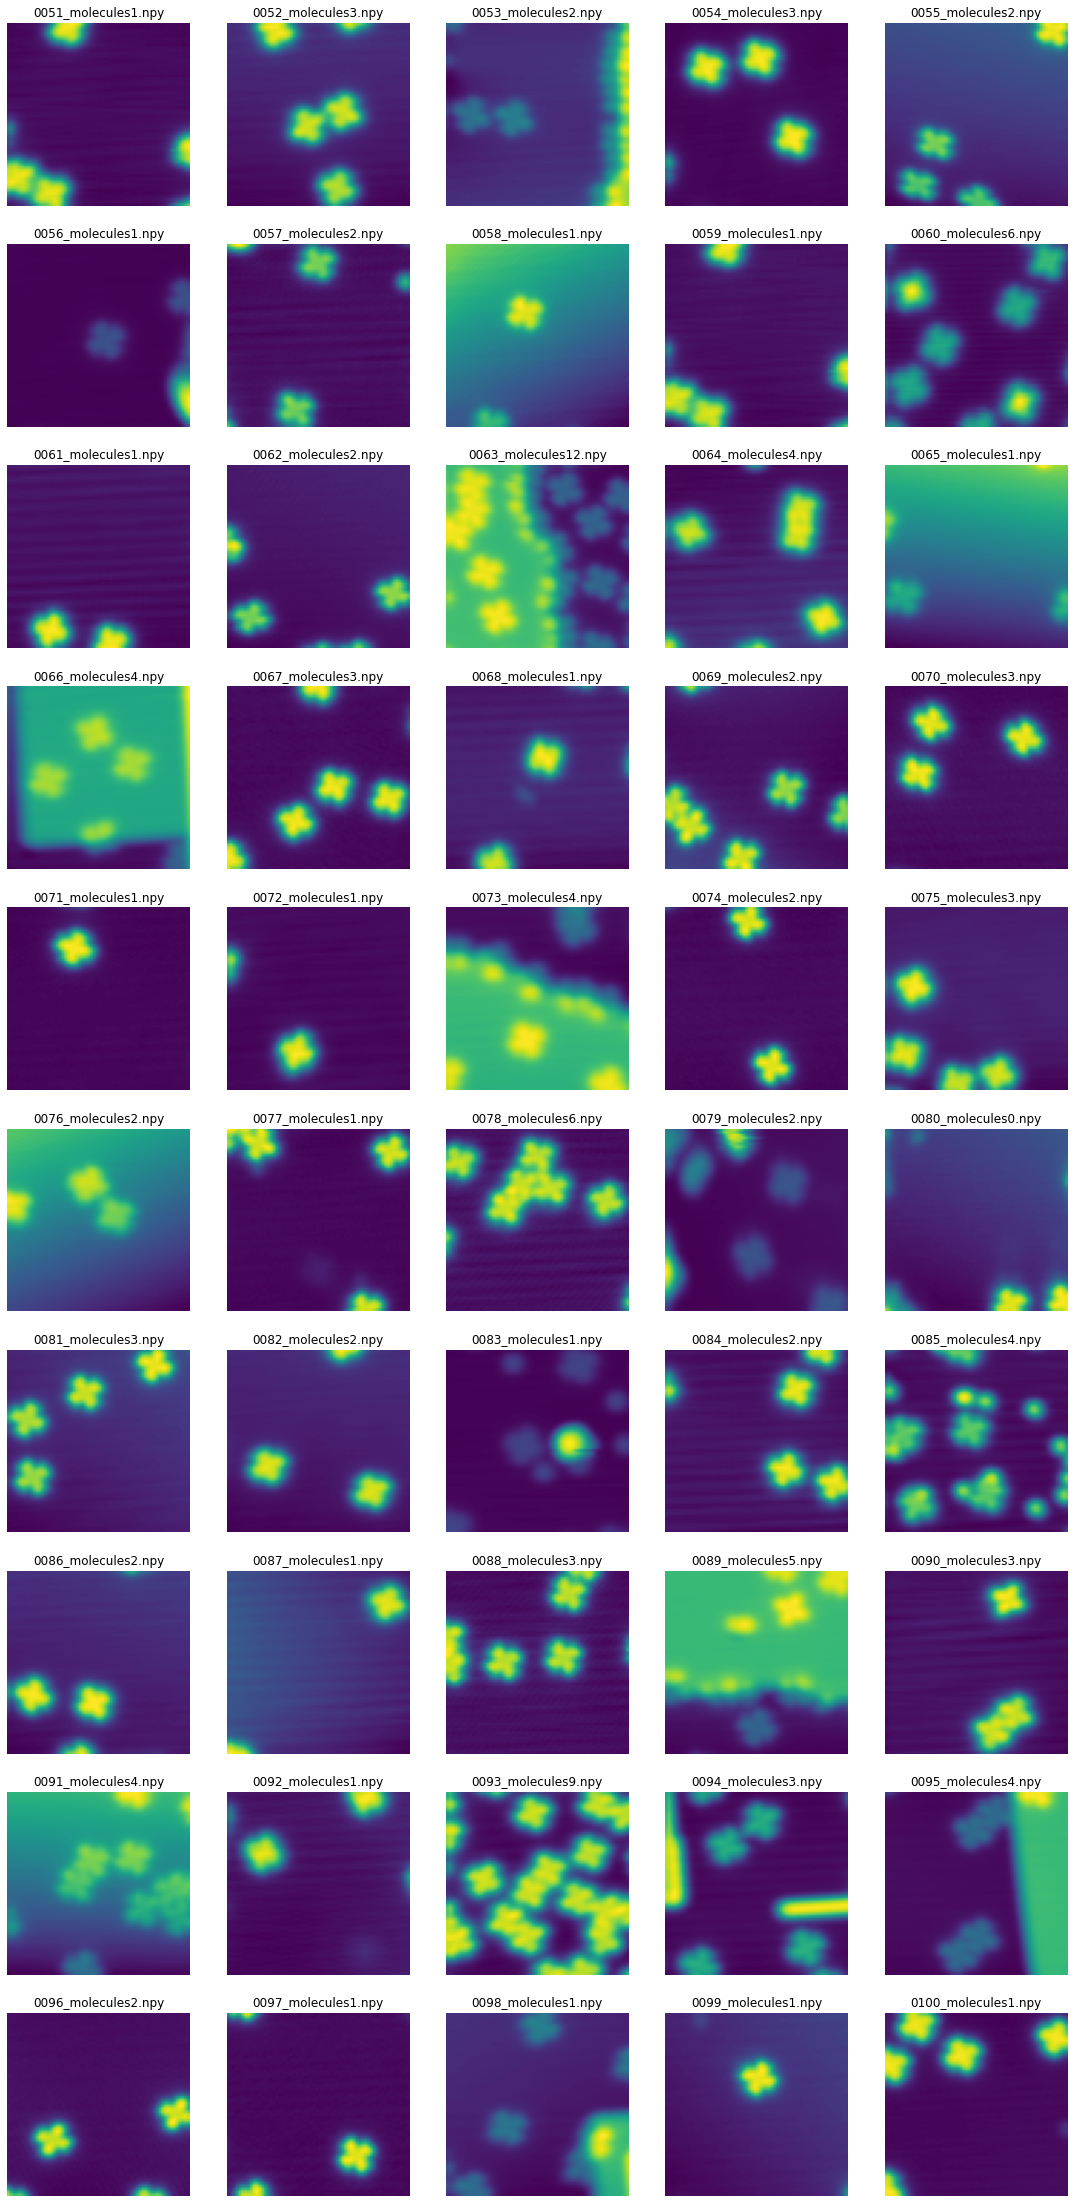

In [7]:
selected_file=all_img[50:100]
fig , axs=plt.subplots(10,int(len(selected_file))//10, figsize=(19,40))
axs=axs.flatten()
for i, im_names in zip(axs,selected_file):
    fpath=os.path.join(root,im_names)
    img=np.load(fpath)
    i.imshow(img)
    i.axis('off')
    i.set_title(im_names)
plt.show()

# Task two: Script to Remove Partial Molecules from the Image

(-0.5, 904.5, 905.5, -0.5)

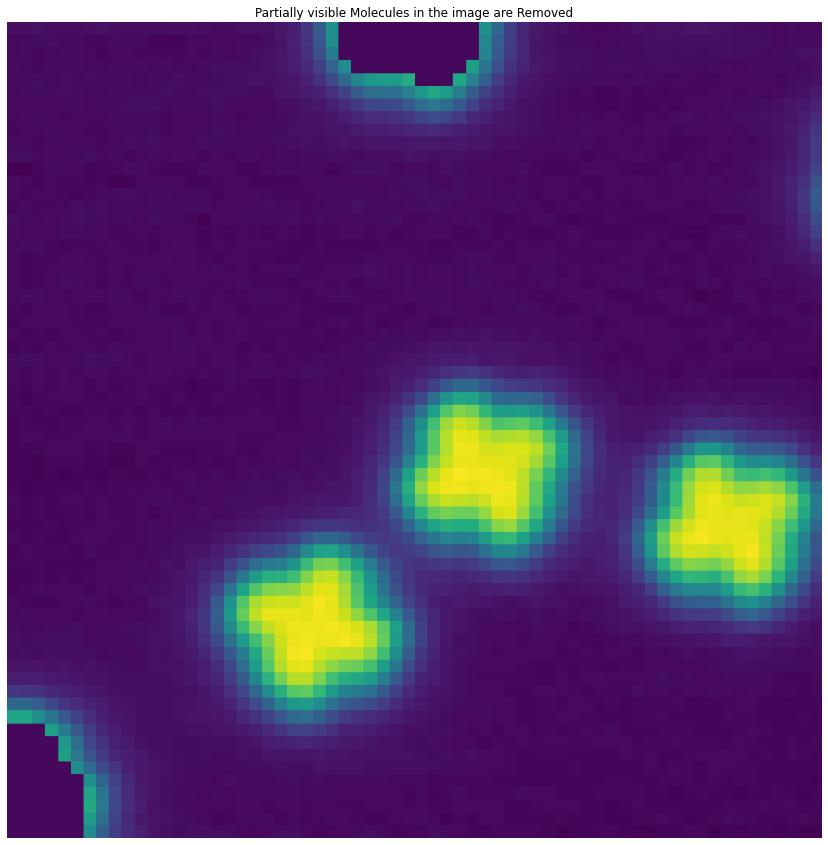

In [5]:
nArray_images = np.load('stm_Ass/0067_molecules3.npy')
#convert numpy data into RGB image
plt.imshow(nArray_images)
plt.axis('off')
plt.savefig('readable_image.png', dpi=300, bbox_inches='tight', pad_inches=0)
plt.close()
#loading image
image=cv2.imread('readable_image.png')
#Formating
original_image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
#Cleaning or filtering by using median Blur
medianF=cv2.medianBlur(original_image,1)
#convertion to gray scale
gray = cv2.cvtColor(medianF, cv2.COLOR_RGB2GRAY)
#Treshold
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# Find contours
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# Creating a mask to keep the objects that are not touching the images boundary
mask = np.ones(thresh.shape, dtype=np.uint8) * 255
# Getting the image dimensions
height, width = thresh.shape
Bg_color=(69, 8, 91)
#Algorithim to clear molecules that are touching the image boundary
for contour in contours:
    # Checking if any point of the contour touches the boundary
    if any(point[0][0] == 0 or point[0][0] == width - 1 or point[0][1] == 0 or point[0][1] == height - 1 for point in contour):
        # Drawing the contour on the mask with images background color
        cv2.drawContours(original_image, [contour], -1, Bg_color, thickness=cv2.FILLED)
    
# Applying the mask to the original image
result = cv2.bitwise_and(original_image, original_image, mask=mask)

# Creating subplots with 1 row and 1 columns to display the result
fig, axes = plt.subplots(figsize=(15, 15))
#Ploting of the objects which are fully visible in the field
cv2.imwrite('partially_visible_molecule_cleared.png',original_image)
axes.imshow(original_image) 
axes.set_title("Partially visible Molecules in the image are Removed")
axes.axis('off')

# Task Three: Scripts to Count the Number of Molecules in the Field

Number of Fully Visible Molecules in the field =  3


(-0.5, 539.5, 699.5, -0.5)

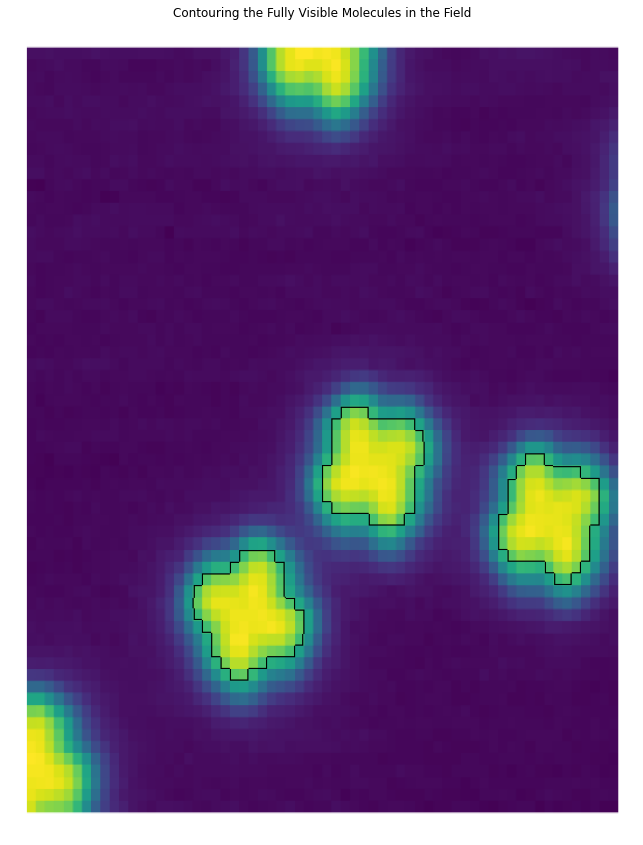

In [6]:
nArray_img=np.load('stm_Ass/0067_molecules3.npy')
#convert numpy data into RGB image
plt.imshow(nArray_img)
plt.axis('off')
plt.savefig('readable_image.png', dpi=300, bbox_inches='tight')
#loading image
imgio=cv2.imread('readable_image.png')
#Formating
BGR2RGB_=cv2.cvtColor(imgio, cv2.COLOR_BGR2RGB)
imgresize=cv2.resize(BGR2RGB_,(540,700),3)
image_copy=imgresize.copy()
#Cleaning or filtering by using median Blur
medianF=cv2.medianBlur(imgresize,1)
#convertion to gray scale
greyS=cv2.cvtColor(medianF,cv2.COLOR_RGB2GRAY)
#Tresholding
ret, th=cv2.threshold(greyS, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
#gerating of contours
contours , _= cv2.findContours(th,cv2.RETR_TREE,cv2.CHAIN_APPROX_NONE)
# Getting the image dimensions
height, width = th.shape
filtered_contours=[]
#Algorithm to check contour if it is lay on the boundaries of the image 
for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    if x > 0 and y > 0 and (x + w) < width and (y + h) < height:
        filtered_contours.append(contour)

#Algorithm to count the contours that are fully visible in the field
contourArea={}
for i in range(len(filtered_contours)):
    count=filtered_contours[i]
    areaCount=cv2.contourArea(count)
    contourArea[i]=areaCount
strCount=sorted(contourArea.items(),key=lambda x:x[1], reverse=True)
results=np.array(strCount).astype("int")
numofMolecule=np.argwhere(results[:, 1]>0).shape[0]
# Itrate over the contour the contours which are selected and draw the shape 
for i in range(1,numofMolecule):
    
  # Ignore contours that are too small or too large
        drawCountour=cv2.drawContours(image_copy,filtered_contours, results[i, 0],(0,0,0),1)
#print the number of fully visible molecules and display the results using matplotlib axis
print('Number of Fully Visible Molecules in the field = ', numofMolecule-1)
plt.close()
fig, axes=plt.subplots(figsize=(15, 15))
axes.imshow(drawCountour)
axes.set_title('Contouring the Fully Visible Molecules in the Field')
cv2.imwrite("counted_molecules.jpg", drawCountour)
axes.axis('off')

# Task Four: Labeling the Molecules Orientation

C:\Users\HADUSH~1\AppData\Local\Temp/ipykernel_20360/1632044146.py:28: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  box = np.int0(box)


(-0.5, 539.5, 699.5, -0.5)

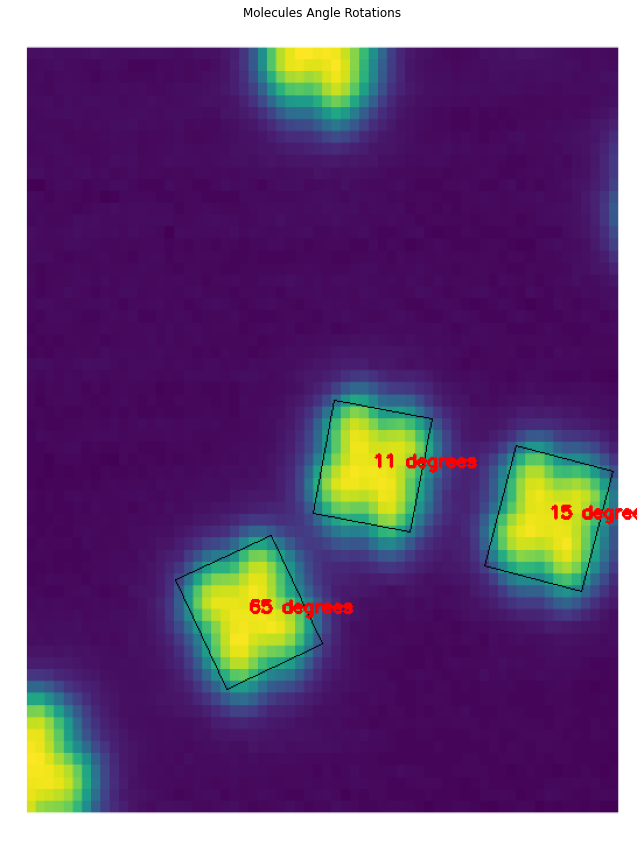

In [7]:
# Load the numpy array data
nArray_img=np.load('stm_Ass/0067_molecules3.npy')
#convert numpy data into RGB image
plt.imshow(nArray_img)
plt.axis('off')
plt.savefig('readable_image.png', dpi=300, bbox_inches='tight')
plt.close()
#load the image
img =cv2.imread("readable_image.png")
#formating of the image
BGR2RGB_=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
imgresize=cv2.resize(BGR2RGB_,(540,700),3)
image_copy=imgresize.copy()
#Cleaning or filtering by using median Blur
medianF=cv2.medianBlur(imgresize,1)
#scalling the images into grayscale
greyS=cv2.cvtColor(medianF,cv2.COLOR_RGB2GRAY)
#tresholding
ret, th=cv2.threshold(greyS, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
#finding the contoure from the treshold
contours , _= cv2.findContours(th,cv2.RETR_TREE,cv2.CHAIN_APPROX_NONE)

# Geting image dimensions
height, width = th.shape
filtered_contours=[]
#Algorithim to check contour if it is laied on the boundaries of the image 
for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    if x > 0 and y > 0 and (x + w) < width and (y + h) < height:
        filtered_contours.append(contour)
#Algorithim to create the orientation of the angle over the contours that are fully visible in the field
for contour in filtered_contours:
    # Get the minimum area rectangle
    rect = cv2.minAreaRect(contour)
    box = cv2.boxPoints(rect)
    box = np.int0(box)

    # Calculating the area of each contour
    area = cv2.contourArea(contour)
    
  # Ignore contours that are too small or too large
    if area < 5700 or 100000 < area:
        continue
    #draw contour
    cv2.drawContours(image_copy, [box], 0, (0,0,0), 1)

    # Checking and calculating the angle orientation in between 0 to 90 degree
    angle = rect[-1]
    if angle < -45:
        angle = 90 + angle
    # Labeling the orientation of the angle
    integer_number = math.ceil(angle)
    label = f"{integer_number} degrees"
    cv2.putText(image_copy, label, (int(rect[0][0]), int(rect[0][1])), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
#displaying the result in the matplotlib axis 
fig,axs=plt.subplots(figsize=(15, 15))
axs.imshow(image_copy)
axs.set_title('Molecules Angle Orientation Estimation')
cv2.imwrite("molecules_orien_estimation.jpg", image_copy)
axs.axis('off')